# Classification - Churn problem

---

## Project Overview

**Objective:** Binary classification to distinguish churned clients:
- `CHURN (1)` - client did not renew their contract after it ended (30 day-window)
- `RENWEAL (0)` - client created a new contract in 30 days or less

**Data:** Aggregated dataset - 1 row per client, merged from 4 source tables:
`BDOSSTOTAL` - `CRC` - `CredScore` - `FAMA`

---

## Notebook Structure

```
 0. SET UP                          Imports, constants, paths 
 1. LOAD DATASET                    Load aggregated client dataset (1 row per client) 
                                    Create mask_pay and mask_active
 2. TRAIN / TEST SPLIT              Split once; drop leaky features + columns with ≥30% and rows with >50% missing values 
 3. BUILD PREPROCESSING PIPELINE    Cleaning > Outliers > Imputation > OHE > FS > Scaling 
 4. MODEL COMPARISON                5-fold CV for LR, RF and HGB with and without oversampling 
 5. BEST-MODEL TUNING               RandomizedSearchCV on best model 
 6. FINAL EVALUATION                predict(X_test_fs), ROC-AUC, report, Confusion Matrix 
 7. DEPLOYMENT                      Model refit, predict for all currently active clients 
```

---

## Anti-Leakage Rules

| Rule | Where enforced |
|---|---|
| `X_test` never influences any decision | Split in Section 2, only used in Section 8 |
| All statistics learned from train fold only | `fit_transform` only on `X_train` in Section 4 |
| Feature selection criteria computed on train only | Section 5 uses `X_train_df` exclusively |
| CV uses only `X_train_fs` | Sections 6 and 7 never touch `X_test_fs` |
| Post-settlement features removed | Section 2 drops 51 leaky features |


## 0. Set Up

In [1]:
#pip install imbalanced-learn

In [2]:
# Standard library 
import sys
import os

# Add the project root to sys.path so that src.code modules are importable
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Load / save helpers
import src.code.io_utils as io_utils 

# Data wrangling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - metrics
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_auc_score,
    classification_report,
)

# Scikit-learn - model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline

from sklearn.base import clone

# Scikit-learn - preprocessing
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler

# Scikit-learn - classifiers 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)

#  Model inspection 
from sklearn.inspection import permutation_importance

#  Hyper-parameter distributions
from scipy.stats import loguniform, randint

# Custom pipeline transformers 
from src.code.class_pipeline_functions import (
    ClientDataCleaner,
    ClientOutlierHandler,
    ClientImputer,
    ClientFeatureEngineer,
    ClientOneHotEncoder,
    ClientFeatureSelection
)

# Imbalanced-learn - pipeline and over-sampling method for imbalanced classification
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Global constants 
RANDOM_STATE = 42   # fixed seed for full reproducibility across runs

# Show all columns when inspecting DataFrames
pd.set_option('display.max_columns', None)

# Path to the Analytical Base Table produced by the data-preparation step
CLIENT_PATH = io_utils.output_path("prepared/abt.parquet")

## 1. Load Dataset

In [3]:
# Load the aggregated ABT (1 row per client)
# The file was produced by notebooks 2a/2b and stored as parquet
client_data = io_utils.load(CLIENT_PATH)
client_data.head(3)

[LOAD] C:\Users\Rui\PycharmProjects\Business_Case_BNP\data\prepared/abt.parquet | shape: (148729, 91)


,CONTRIB,N_CONTRACTS,HAS_ACTIVE,FIRST_DCREAT,LAST_DCREAT,LAST_DPOS,LAST_DATFIN,FIRST_D1FIN,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,LAST_RISK,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,NBENF,PRODALP,EVER_SOL,N_SOL,EVER_SAN,N_SAN,EVER_RBT,N_RBT,LAST_OBS_DATE_SOL,LAST_OBS_DATE_SAN,LAST_OBS_DATE_RBT,IS_EARLY_SETTLER,IS_CHURN,TIME_TO_CHURN_D,MT_MENSAL_MIN,MT_MENSAL_MAX,MT_MENSAL_MEDIAN,COUNT_CL_MIN,COUNT_CL_MAX,COUNT_CL_MEDIAN,COUNT_AUTO_MIN,COUNT_AUTO_MAX,COUNT_AUTO_MEDIAN,COUNT_TOTAL_MIN,COUNT_TOTAL_MAX,COUNT_TOTAL_MEDIAN,MONTVENC_CL_MIN,MONTVENC_CL_MAX,MONTVENC_CL_MEDIAN,MONTVENC_CP_MIN,MONTVENC_CP_MAX,MONTVENC_CP_MEDIAN,MONTVENC_AUTO_MIN,MONTVENC_AUTO_MAX,MONTVENC_AUTO_MEDIAN,MONTVENC_HT_MIN,MONTVENC_HT_MAX,MONTVENC_HT_MEDIAN,DIVIDAS_CL_MIN,DIVIDAS_CL_MAX,DIVIDAS_CL_MEDIAN,DIVIDAS_CP_MIN,DIVIDAS_CP_MAX,DIVIDAS_CP_MEDIAN,DIVIDAS_AUTO_MIN,DIVIDAS_AUTO_MAX,DIVIDAS_AUTO_MEDIAN,DIVIDAS_HT_MIN,DIVIDAS_HT_MAX,DIVIDAS_HT_MEDIAN,sys_data_procura,kp_sqe_enc,ks_score_tier,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2,0,2024-06-25,2024-09-13,2025-11-17,2024-09-30,2024-06-27,84.0,120.0,102.0,3.0,13.0,8.0,19.0,19.0,19.0,24000.00,24000.00,438.761355,0.000,0.0,0.0,0.0,000000000000000000000000,0.0,1513.466,1513.466,1513.466,80.0,0.0,EP,0,0,1,2,0,0,NaT,2025-11-30,NaT,1,1,443.0,0.00,0.00,0.00,0.0,1.0,0.0,0.0,6.0,1.0,5.0,18.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,8000.00,0.00,1.65,3701.73,978.25,0.0,58633.86,15934.05,0.0,0.0,0.0,2025-02-05,7.0,2.0,10.0,1.0,2.0,-438.9,10.0,S,F,33.0
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,1,1,2018-03-29,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,120.0,120.0,91.0,91.0,91.0,91.0,91.0,91.0,20000.00,20000.00,347.447280,8115.247,0.0,0.0,0.0,000000000000000000000000,0.0,1113.258,1113.258,1113.258,80.0,1.0,EP,0,0,0,0,0,0,NaT,NaT,NaT,0,0,NaN,538.67,547.45,545.07,4.0,12.0,4.0,0.0,0.0,0.0,10.0,30.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20308.94,69754.56,24983.22,5499.88,21274.83,7115.46,0.0,0.00,0.00,0.0,0.0,0.0,2025-04-09,3.0,1.0,10.0,1.0,0.0,1166.9,10.0,C,P,52.0
2,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,2,0,2001-09-21,2001-09-27,2014-06-27,2001-10-04,2001-09-21,60.0,60.0,60.0,21.0,21.0,21.0,21.0,21.0,21.0,19453.11,19453.11,608.913796,0.000,0.0,2.0,24.0,444444444444444444444444,0.0,678.483,678.483,678.483,60.0,2.0,EP,1,2,0,0,0,0,2024-03-31,NaT,NaT,0,1,8221.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN


In [4]:
# People who have ended at least one contract (training the model with them)
mask_pay = client_data[client_data[["EVER_SAN", "EVER_SOL", "EVER_RBT"]].eq(1).any(axis=1)] 

# Active clients (deploying the model on them)
mask_active = client_data[client_data["HAS_ACTIVE"]==1]

In [5]:
mask_pay["IS_CHURN"].value_counts()

IS_CHURN
1    49733
0    17707
Name: count, dtype: int64

## 2. Train / Test Split

We define the target column and explicitly list every column that must be
**dropped before modelling**.  Each is dropped for one of four reasons:

1. **Target leakage** - features that encode partial or full knowledge of the outcome.
2. **Identifiers / metadata** - columns that carry no predictive signal.
3. **Raw date columns** - not suitable for tree-based models.
4. **Post-settlement features (Phases 1 & 2)** - features aggregated from observations
   using `'last'`/`'max'` that capture the state **after** settlement events, or
   temporal FAMA/CRC aggregations that span the post-settlement timeline.


In [6]:
# Define target and columns to exclude

target = 'IS_CHURN'          # churn label 

drop_cols = [
    # Target and direct leakage
    target,                   # the label itself
    'HAS_ACTIVE',             # leak: directly correlates with active status (inverse of churn)
    'EVER_SAN',               # leak: directly reveals SAN history
    'EVER_SOL',               # leak: directly reveals SOL history
    'N_SAN',                  # leak: count of SAN events
    'N_SOL',                  # leak: count of SOL events
    'EVER_RBT',               # leak: reveals RBT (reimbursement) events
    'N_RBT',                  # leak: count of RBT events
    'IS_SAN',                 # leak: binary SAN flag
    'IS_EARLY_SETTLER',       # 1 = SAN (early), 0 = SOL (on time)

    # Date columns with leakage risk
    'LAST_OBS_DATE_SOL',      # leak: date of last SOL observation
    'LAST_OBS_DATE_SAN',      # leak: date of last SAN observation
    'LAST_OBS_DATE_RBT',      # leak: date of last RBT observation
    'TIME_TO_CHURN_D',        # leak: time to churn in days

    # Phase 1 Leakage: Post-settlement BDOSS aggregations
    'TOTAL_CRD',              # residual credit at last obs -> 0 after payoff
    'TOTAL_SREC',             # recovery amount, only exists post-default
    'TOTAL_RN',               # nominal remaining, changes at settlement
    'TOTAL_RD',               # debt remaining, changes at settlement
    'LAST_RISK',              # risk score at last observation (post-settlement)
    'MAX_RISKA',              # max risk score (accumulates post-event info)
    'LAST_DPOS',              # date of last POS observation, approx settlement date
    'LAST_DATFIN',            # last contract end date, tied to settlement
    'FIRST_D1FIN',            # first contract end date, tied to settlement

    # Phase 2 Leakage: Temporal aggregations across client history (FAMA & CRC)
    # These use `.last()`, `.min()`, `.max()` over post-settlement data.
    'MT_MENSAL_MIN', 'MT_MENSAL_MAX',
    'COUNT_CL_MIN', 'COUNT_CL_MAX',
    'COUNT_AUTO_MIN', 'COUNT_AUTO_MAX',
    'COUNT_TOTAL_MIN', 'COUNT_TOTAL_MAX',
    'MONTVENC_CL_MIN', 'MONTVENC_CL_MAX',
    'MONTVENC_CP_MIN', 'MONTVENC_CP_MAX',
    'MONTVENC_AUTO_MIN', 'MONTVENC_AUTO_MAX',
    'MONTVENC_HT_MIN', 'MONTVENC_HT_MAX', 
    'DIVIDAS_CL_MIN', 'DIVIDAS_CL_MAX',
    'DIVIDAS_CP_MIN', 'DIVIDAS_CP_MAX',
    'DIVIDAS_AUTO_MIN', 'DIVIDAS_AUTO_MAX',
    'DIVIDAS_HT_MIN', 'DIVIDAS_HT_MAX',
# adicionar os dividas_total etc

    # Raw date columns (not model-ready)
    'FIRST_DCREAT',           # date: first contract creation
    'LAST_DCREAT',            # date: last contract creation

    # Client ID (not predictive, just an identifier)
    'sys_data_procura',         # date: extraction date (not predictive)
    'CONTRIB'
]

# Drop columns with >= 30% missing values - found on 3b notebook
cols_to_drop = ['LAST_OBS_DATE_RBT', 'LAST_OBS_DATE_SOL', 'LAST_OBS_DATE_SAN',
                'sys_data_procura', 'kp_sqe_enc', 'ks_score_tier']

# Drop rows with > 50% missing values
threshold = 0.5
min_non_null = int(threshold * client_data.shape[1])  # minimum non-null values required
rows_before = client_data.shape[0]
client_data.dropna(thresh=min_non_null, inplace=True)
rows_after = client_data.shape[0]
print(f"Dropped {rows_before - rows_after} rows with > 50% missing values")
print(f"New shape: {client_data.shape}")

Dropped 1246 rows with > 50% missing values
New shape: (147483, 91)


In [7]:
# Build modelling dataset after row filtering
# masks must be recomputed from the cleaned dataset to keep indices aligned

mask_pay = client_data[
    client_data[["EVER_SAN", "EVER_SOL", "EVER_RBT"]].eq(1).any(axis=1)
]

mask_active = client_data[client_data["HAS_ACTIVE"]==1]

# Drop leakage features + high-missing columns
X = mask_pay.drop(columns=drop_cols + cols_to_drop, errors="ignore")

# Target
y = mask_pay[target]

# Sanity check: binary target
assert y.nunique() == 2, (
    f"Expected a binary target, but found {y.nunique()} values: {y.unique()}"
)

print(f"All specified leaky/high-missing features dropped.")
print(f"Raw predictors before encoding: {X.shape[1]}")
print(f"Dataset shape used for modelling: {X.shape}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"\nTrain : {X_train.shape} | Churn rate: {y_train.mean():.2%}")
print(f"Test  : {X_test.shape} | Churn rate: {y_test.mean():.2%}")

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

All specified leaky/high-missing features dropped.
Raw predictors before encoding: 39
Dataset shape used for modelling: (66194, 39)

Train : (52955, 39) | Churn rate: 73.25%
Test  : (13239, 39) | Churn rate: 73.25%


## 3. Build Preprocessing Pipeline


In [8]:
scaler = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), make_column_selector(dtype_include="number"))
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

base_steps = [
    ("cleaning", ClientDataCleaner(
        datetime_cols=[],
        cols_to_remove=[],
        numeric_ranges={},
        verbose=False,
    )),
    ("outliers", ClientOutlierHandler(
        methods=("iqr", "mod_z"),
        min_votes=2,
        iqr_k=1.5,
        exclude_cols=["CSP"],
        verbose=False,
    )),
    ("imputer", ClientImputer(
        numeric_strategy="median",
        datetime_strategy="ffill",
        verbose=False,
    )),
    ("encoder", ClientOneHotEncoder(
        cols=["sdem_SITFAM", "sdem_HABITAT", "CSP", "PRODALP"],
        drop_first=False,
        verbose=False,
    )),
    ("scaler", scaler),
    ("feature_selection", ClientFeatureSelection(
        corr_threshold=0.90,
        use_lasso=True,
        use_rfe=True,
        use_rf=True,
        min_votes=2,
        lasso_C=0.1,
        rfe_fraction=0.6,
        rfe_step=0.1,
        rf_threshold="median",
        random_state=RANDOM_STATE,
        verbose=False,
    )),
]

In [9]:
def build_pipeline(model, use_smote=False):
    steps = base_steps.copy()

    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))

    steps.append(("model", clone(model)))

    return ImbPipeline(steps=steps)

## 4. Model Comparison

In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "HistGBM": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_iter=100
    ),
}

resampling_strategies = {
    "No SMOTE": False,
    "SMOTE": True,
}

results = []

for model_name, clf in models.items():
    for strategy_name, use_smote in resampling_strategies.items():

        pipe = build_pipeline(clf, use_smote=use_smote)

        print(f"Training {model_name} | {strategy_name}...")

        cv_res = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
            return_train_score=True,
        )

        results.append({
            "Model": model_name,
            "Resampling": strategy_name,
            "Train ROC-AUC": cv_res["train_score"].mean(),
            "Val ROC-AUC": cv_res["test_score"].mean(),
            "Std Val AUC": cv_res["test_score"].std(),
            "Train-Val Gap": cv_res["train_score"].mean() - cv_res["test_score"].mean(),
        })

results_df = pd.DataFrame(results).sort_values(
    by=["Val ROC-AUC", "Std Val AUC"],
    ascending=[False, True]
).reset_index(drop=True)

display(results_df)

Training Logistic Regression | No SMOTE...
Training Logistic Regression | SMOTE...
Training Random Forest | No SMOTE...
Training Random Forest | SMOTE...
Training HistGBM | No SMOTE...
Training HistGBM | SMOTE...


,Model,Resampling,Train ROC-AUC,Val ROC-AUC,Std Val AUC,Train-Val Gap
0,HistGBM,No SMOTE,0.993871,0.982051,0.000748,0.011820
1,HistGBM,SMOTE,0.993778,0.981406,0.000376,0.012372
2,Random Forest,No SMOTE,1.000000,0.980795,0.000307,0.019205
3,Random Forest,SMOTE,1.000000,0.979157,0.000802,0.020843
4,Logistic Regression,No SMOTE,0.973519,0.973207,0.001014,0.000312
5,Logistic Regression,SMOTE,0.973476,0.973162,0.000982,0.000314


In [11]:
best_row = results_df.iloc[0]

best_model_name = best_row["Model"]
best_resampling = best_row["Resampling"]
use_smote_best = (best_resampling == "SMOTE")

print("Best baseline combination:")
print(f"  Model      : {best_model_name}")
print(f"  Resampling : {best_resampling}")
print(f"  Val ROC-AUC: {best_row['Val ROC-AUC']:.4f}")

Best baseline combination:
  Model      : HistGBM
  Resampling : No SMOTE
  Val ROC-AUC: 0.9821


## 5. Best-Model Tuning

In [12]:
if best_model_name == "Logistic Regression":
    best_clf = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    )

elif best_model_name == "Random Forest":
    best_clf = RandomForestClassifier(
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

elif best_model_name == "HistGBM":
    best_clf = HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )

else:
    raise ValueError(f"Unknown model: {best_model_name}")

In [13]:
common_fs_params = {
    "feature_selection__corr_threshold": [0.85, 0.90, 0.95],
    "feature_selection__lasso_C": [0.01, 0.05, 0.1, 0.5],
    "feature_selection__rfe_fraction": [0.4, 0.5, 0.6, 0.7],
    "feature_selection__min_votes": [1, 2],
}

if best_model_name == "Logistic Regression":
    model_params = {
        "model__C": [0.01, 0.1, 1.0, 5.0, 10.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    }

elif best_model_name == "Random Forest":
    model_params = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }

elif best_model_name == "HistGBM":
    model_params = {
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_iter": [100, 200, 300],
        "model__max_depth": [None, 3, 5, 7],
        "model__min_samples_leaf": [10, 20, 30],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    }

param_dist = {}
param_dist.update(common_fs_params)
param_dist.update(model_params)

if use_smote_best:
    param_dist["smote__k_neighbors"] = [3, 5, 7]

In [14]:
tuning_pipe = build_pipeline(best_clf, use_smote=use_smote_best)

In [15]:
search = RandomizedSearchCV(
    estimator=tuning_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

search.fit(X_train, y_train)

print("Best params:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params:
{'model__min_samples_leaf': 10, 'model__max_iter': 300, 'model__max_depth': None, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.0, 'feature_selection__rfe_fraction': 0.6, 'feature_selection__min_votes': 2, 'feature_selection__lasso_C': 0.1, 'feature_selection__corr_threshold': 0.95}

Best CV ROC-AUC:
0.9827373215509448


## 6. Final Evaluation

FINAL TEST SET RESULTS
Best model      : HistGBM
Resampling      : No SMOTE
Test ROC-AUC    : 0.9836

              precision    recall  f1-score   support

     Renewal       0.86      0.99      0.92      3541
       Churn       1.00      0.94      0.97      9698

    accuracy                           0.95     13239
   macro avg       0.93      0.97      0.94     13239
weighted avg       0.96      0.95      0.96     13239



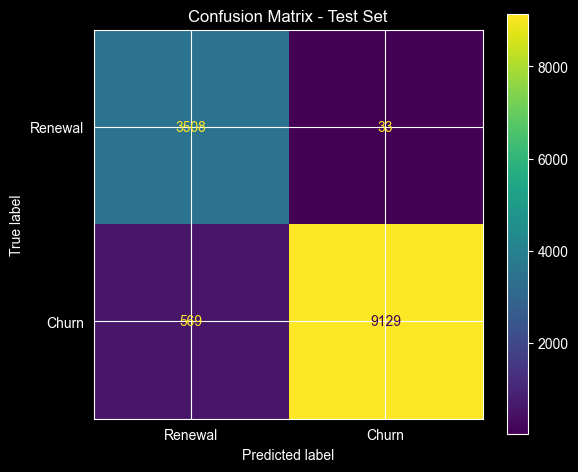

In [16]:
best_pipe = search.best_estimator_

y_test_prob = best_pipe.predict_proba(X_test)[:, 1]
y_test_pred = best_pipe.predict(X_test)

print("=" * 50)
print("FINAL TEST SET RESULTS")
print("=" * 50)

roc_auc = roc_auc_score(y_test, y_test_prob)
print(f"Best model      : {best_model_name}")
print(f"Resampling      : {best_resampling}")
print(f"Test ROC-AUC    : {roc_auc:.4f}")
print()

print(classification_report(y_test, y_test_pred, target_names=["Renewal", "Churn"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Renewal", "Churn"],
    ax=ax,
)
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

## 7. Deployment
### 7.1. Model Refit 

In [17]:
# Refit the model on all available data (train + test) for deployment 
deployment_pipe = clone(search.best_estimator_)
deployment_pipe.fit(X, y)

,steps,"[('cleaning', ...), ('outliers', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,datetime_cols,[]
,cols_to_remove,[]
,datetime_format,None
,numeric_ranges,{}
,categorical_maps,None
,verbose,False
,cols,None


### 7.2. Active Clients Predictions

In [18]:
# Predict churn probabilities for currently active clients

# Rebuild active-clients subset from the cleaned client_data
mask_active = client_data[client_data["HAS_ACTIVE"] == 1].copy()

# Keep client identifier separately
contrib_active = mask_active["CONTRIB"].reset_index(drop=True)

# Build modelling matrix for active clients
# Drop the same leakage / high-missing columns used in training
X_active = mask_active.drop(columns=drop_cols + cols_to_drop, errors="ignore")

print(f"Active clients raw matrix: {X_active.shape}")

# Sanity check: active clients should not contain the target as a predictor
assert target not in X_active.columns, f"{target} should not be present in X_active."

# Generate predictions directly from the FULL fitted pipeline
y_active_pred = deployment_pipe.predict(X_active)
y_active_prob = deployment_pipe.predict_proba(X_active)[:, 1]

# Build scored output
churn_scores = (
    pd.DataFrame({
        "CONTRIB": contrib_active,
        "Prob_Churn": y_active_prob,
        "Pred_Churn_Label": y_active_pred,
    })
    .sort_values(by="Prob_Churn", ascending=False)
    .reset_index(drop=True)
)

# merge scores back into the active-clients table
output_path = io_utils.output_path("prepared/active_clients_scored.parquet")

try:
    scored = io_utils.load(output_path)
    scored = scored.drop(columns=["Prob_Churn", "Pred_Churn_Label"], errors="ignore")
except FileNotFoundError:
    scored = mask_active.copy()

scored = scored.merge(churn_scores, on="CONTRIB", how="left")
io_utils.save(scored, output_path)

io_utils.save(scored, io_utils.output_path("prepared/active_clients_scored.parquet"))

print("=" * 50)
print("ACTIVE CLIENTS - PREDICTED CHURN")
print("=" * 50)
print(f"Total active clients scored: {len(churn_scores)}")

churn_scores

Active clients raw matrix: (98976, 39)
[LOAD] C:\Users\Rui\PycharmProjects\Business_Case_BNP\data\prepared/active_clients_scored.parquet | shape: (98976, 93)
[SAVE] C:\Users\Rui\PycharmProjects\Business_Case_BNP\data\prepared/active_clients_scored.parquet | shape: (98976, 95)
[SAVE] C:\Users\Rui\PycharmProjects\Business_Case_BNP\data\prepared/active_clients_scored.parquet | shape: (98976, 95)
ACTIVE CLIENTS - PREDICTED CHURN
Total active clients scored: 98976


,CONTRIB,Prob_Churn,Pred_Churn_Label
0,d10e43f4f14d125957af9b4acafd1a62f453cd4fd5d459...,0.999911,1
1,0423354542e5f0512724f10527e1facd9e9276d5bf455e...,0.999907,1
2,c09ae50229feacfce80e1e791d3059314c058ec0e33daf...,0.999893,1
3,57b6f1a8de9cebfb780a4f95ba040b3f36217f667378cd...,0.999893,1
4,d2e691c25ca98c00c08408c279c9fec4d1cd1408ad505a...,0.999893,1
...,...,...,...
98971,220c3d735568944456ffd0d1cc2052afe95f8a66f9c794...,0.021856,0
98972,bb325f1b2be70b87d33c0a3be5edc241015098e6e07013...,0.020773,0
98973,bb430b88f6dccb4b01c92f87a5734ca95920477b61c491...,0.020556,0
98974,c51255c8aa3effbb0ee7cac71fffd2a906512bcb1b7674...,0.019762,0


In [19]:
label_counts = churn_scores['Pred_Churn_Label'].value_counts().sort_index()

print(f"Predicted 0s (renewal): {label_counts.get(0, 0)}")
print(f"Predicted 1s (churn): {label_counts.get(1, 0)}")

Predicted 0s (renewal): 23255
Predicted 1s (churn): 75721


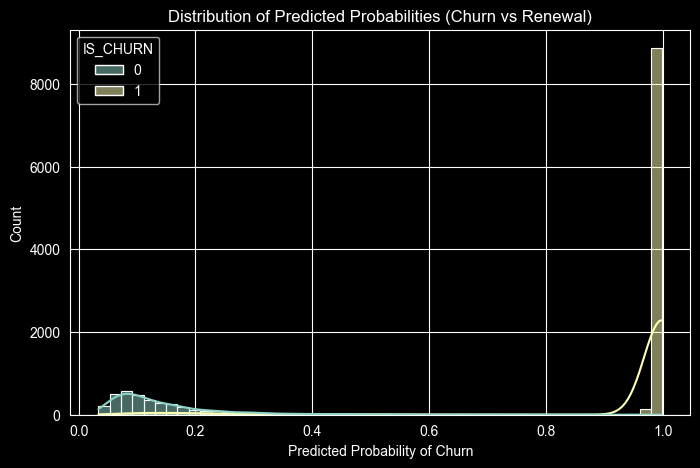

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(x=y_test_prob, hue=y_test, bins=50, kde=True, common_norm=False)
plt.title('Distribution of Predicted Probabilities (Churn vs Renewal)')
plt.xlabel('Predicted Probability of Churn')
plt.show()